# Supervised ViT — Feature Extraction & Invariance Analysis (raw)

Same as `invariance_Supervised_vit.ipynb` but features are **not** pooled.
All 64 patch tokens are flattened → `(B, 64×768)` per layer.
Tokens are z-scored across the feature dimension before flattening.

In [1]:
import os, sys
import torch
import numpy as np
from PIL import Image
from scipy.io import loadmat
from transformers import AutoImageProcessor, ViTModel
import matplotlib.pyplot as plt

sys.path.append('../utils')
import util

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## Load Supervised ViT

In [2]:
repo_id = 'google/vit-base-patch16-224'
processor = AutoImageProcessor.from_pretrained(repo_id)
model = ViTModel.from_pretrained(repo_id).to(device).eval()

n_layers    = model.config.num_hidden_layers   # 12
patch_start = 1                                # skip CLS token only
layer_names = [f'B{i}' for i in range(1, n_layers + 1)]

print(f'num_hidden_layers: {n_layers}')
print(f'hidden_size      : {model.config.hidden_size}')
print(f'patch_size       : {model.config.patch_size}')

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


num_hidden_layers: 12
hidden_size      : 768
patch_size       : 16


## Load & preprocess images

In [3]:
mat = loadmat('../data/miguel_passive8x4.mat')
images_gray = np.transpose(mat['img'].astype(np.float32), (2, 0, 1))  # (32, 150, 600)
nimg = len(images_gray)
print(f'images_gray: {images_gray.shape}  range: {images_gray.min():.0f}–{images_gray.max():.0f}')

images_rgb = [
    Image.fromarray(images_gray[i].astype(np.uint8)).resize((256, 64), Image.BICUBIC).convert('RGB')
    for i in range(nimg)
]
print(f'prepared {nimg} images, size: {images_rgb[0].size}')

images_gray: (32, 150, 600)  range: 0–255
prepared 32 images, size: (256, 64)


## Extract hidden states

In [4]:
inputs = processor(images=images_rgb, return_tensors='pt',
                   do_resize=False, do_center_crop=False)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True, interpolate_pos_encoding=True)

hidden = np.stack([h.cpu().numpy() for h in outputs.hidden_states], axis=0)  # (13, 32, 65, 768)
print('hidden states shape:', hidden.shape)

hidden = hidden[1:]   # (12, 32, 65, 768) — drop embedding
print('after dropping embedding:', hidden.shape)

/home/carsen/anaconda3/envs/dinov3_env/lib/python3.10/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `ViTImageProcessor.preprocess` and were ignored: 'do_center_crop'
  return self.preprocess(images, *args, **kwargs)


hidden states shape: (13, 32, 65, 768)
after dropping embedding: (12, 32, 65, 768)


## Z-score across feature dim, then flatten patch tokens

In [5]:
mean = hidden.mean(axis=-1, keepdims=True)
std  = hidden.std(axis=-1,  keepdims=True)
hidden_z = (hidden - mean) / (std + 1e-6)   # (12, 32, 65, 768)

# Patch tokens: skip CLS (index 0), flatten 64 patches × 768 dims
patch_tokens = hidden_z[:, :, patch_start:, :]        # (12, 32, 64, 768)
flat = patch_tokens.reshape(n_layers, nimg, -1)        # (12, 32, 49152)

print('patch_tokens shape:', patch_tokens.shape)
print('flat         shape:', flat.shape)

features = np.empty(n_layers, dtype=object)
for i in range(n_layers):
    features[i] = flat[i]   # (32, 49152)
    print(f'  {layer_names[i]}: {features[i].shape}')

patch_tokens shape: (12, 32, 64, 768)
flat         shape: (12, 32, 49152)
  B1: (32, 49152)
  B2: (32, 49152)
  B3: (32, 49152)
  B4: (32, 49152)
  B5: (32, 49152)
  B6: (32, 49152)
  B7: (32, 49152)
  B8: (32, 49152)
  B9: (32, 49152)
  B10: (32, 49152)
  B11: (32, 49152)
  B12: (32, 49152)


## Compute invariance

In [6]:
rep_mtx  = util.compute_model_rep_mtx(features)
invar_df = util.compute_pair_inv_model(rep_mtx)
print('Invariance computed.')

Invariance computed.


## Summarise and save

In [7]:
inv_values = np.array([
    invar_df[invar_df['layer'] == il]['pair_invariance'].values
    for il in range(n_layers)
])   # (n_layers, 28)

inv_summary = {
    'layer_names': layer_names,
    'values': inv_values,
}

os.makedirs('outputs', exist_ok=True)
np.save('outputs/sup_vit_inv_raw.npy', inv_summary, allow_pickle=True)
np.save('outputs/sup_vit_flat_features.npy', features, allow_pickle=True)
print('Saved.')

mean = inv_values.mean(axis=1)
sem  = inv_values.std(axis=1) / np.sqrt(inv_values.shape[1])
print('\nPer-block mean ± SEM invariance:')
for name, m, s in zip(layer_names, mean, sem):
    print(f'  {name}: {m:.4f} ± {s:.4f}')

Saved.

Per-block mean ± SEM invariance:
  B1: 0.0108 ± 0.0017
  B2: 0.0464 ± 0.0049
  B3: 0.1141 ± 0.0114
  B4: 0.1156 ± 0.0103
  B5: 0.1201 ± 0.0101
  B6: 0.1240 ± 0.0102
  B7: 0.1309 ± 0.0104
  B8: 0.1525 ± 0.0112
  B9: 0.1520 ± 0.0108
  B10: 0.1487 ± 0.0101
  B11: 0.1458 ± 0.0084
  B12: 0.2031 ± 0.0110


## Plot

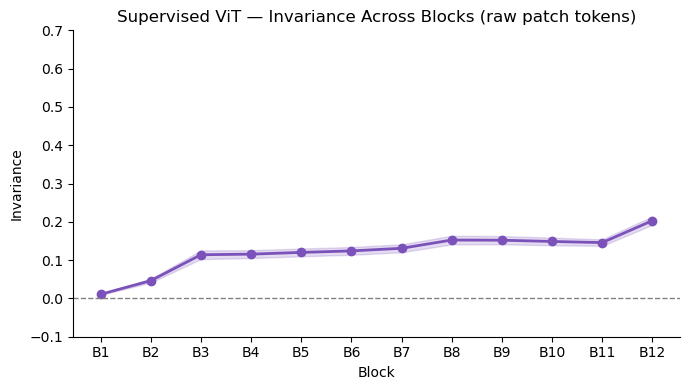

In [8]:
values = inv_summary['values']
mean   = values.mean(axis=1)
sem    = values.std(axis=1) / np.sqrt(values.shape[1])
x      = np.arange(n_layers)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, mean, 'o-', color='#7b52b9', lw=2, ms=6)
ax.fill_between(x, mean - sem, mean + sem, alpha=0.2, color='#7b52b9')
ax.axhline(0, color='gray', lw=1, linestyle='--')
ax.set_ylim(-0.1, 0.7)
ax.set_xticks(x)
ax.set_xticklabels(layer_names, fontsize=10)
ax.set_xlabel('Block')
ax.set_ylabel('Invariance')
ax.set_title('Supervised ViT — Invariance Across Blocks (raw patch tokens)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/sup_vit_invariance_raw.png', dpi=300, bbox_inches='tight')
plt.show()